# Réseau de Neurones From Scratch
## Comprendre chaque engrenage — Mode Epitech

---

### Objectif final
Construire un réseau de neurones **entièrement à la main avec NumPy**, capable de reconnaître
des chiffres manuscrits (MNIST). Pas de TensorFlow, pas de Keras, pas de magie noire.
Chaque multiplication matricielle, chaque dérivée, chaque mise à jour de poids — c'est TOI qui les codes.

### Stack technique
- **Python 3.10+**
- **NumPy** — calcul matriciel
- **Matplotlib** — visualisation
- **C'est tout.** Pas de framework ML.

---

### Plan du cours

| Module | Thème | Concepts clés |
|--------|-------|---------------|
| 0 | Setup & Maths de base | Imports, produit matriciel, dimensions |
| 1 | Le Neurone | Somme pondérée, biais, fonction d'activation |
| 2 | Fonctions d'Activation | Sigmoid, ReLU, Softmax — et leurs dérivées |
| 3 | Forward Propagation | Propagation couche par couche, de l'entrée à la sortie |
| 4 | Loss Functions | MSE, Cross-Entropy — mesurer l'erreur du réseau |
| 5 | Backpropagation | La chain rule, calcul des gradients, le cœur du deep learning |
| 6 | Gradient Descent | Mise à jour des poids, learning rate, mini-batch |
| 7 | Assemblage — Classe NeuralNetwork | Tout assembler dans une classe propre |
| 8 | Entraînement sur MNIST | Boucle de training, évaluation, visualisation |
| 9 | Améliorations & Réflexion | Momentum, He init, learning rate decay, comparaison Keras |

---

### Règles du mode Epitech
- Les cellules **`# TODO`** sont à compléter par toi.
- Les hints te guident **sans donner la solution complète**.
- Google, Wikipedia, la doc NumPy : **tout est permis**.
- Si tu bloques, relis la théorie dans les cellules Markdown au-dessus du TODO.

---

### Résumé d'avancement

```
[x] Module 0 — Setup & Maths
[ ] Module 1 — Le Neurone
[ ] Module 2 — Fonctions d'Activation
[ ] Module 3 — Forward Propagation
[ ] Module 4 — Loss Functions
[ ] Module 5 — Backpropagation
[ ] Module 6 — Gradient Descent
[ ] Module 7 — Assemblage
[ ] Module 8 — Entraînement MNIST
[ ] Module 9 — Améliorations
```

---
## Module 0 — Setup & Rappels Mathématiques

**Objectif** : Vérifier que tu maîtrises les opérations matricielles de base.
Tout le réseau repose là-dessus.

### Rappels essentiels

**Produit matriciel (dot product)** :
- Si `A` est de shape `(m, n)` et `B` de shape `(n, p)`, alors `A @ B` est de shape `(m, p)`.
- C'est l'opération fondamentale d'un réseau de neurones.

**Transposée** : `A.T` inverse lignes et colonnes `(m, n) → (n, m)`

**Broadcasting** : NumPy étend automatiquement les dimensions pour additionner
des matrices de shapes compatibles (ex: `(3, 4) + (1, 4)` fonctionne).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

print(f'NumPy version : {np.__version__}')
print('Prêt — aucun framework ML importé, on fait tout à la main !')

NumPy version : 2.4.3
Prêt — aucun framework ML importé, on fait tout à la main !


In [2]:
# TODO: Échauffement matriciel
# 1. Crée une matrice A de shape (3, 4) remplie de valeurs aléatoires
# 2. Crée une matrice B de shape (4, 2) remplie de valeurs aléatoires
# 3. Calcule le produit matriciel C = A @ B
# 4. Affiche les shapes de A, B et C
# 5. Vérifie : C doit être de shape (3, 2) — pourquoi ?
#
# Hint: np.random.randn() génère des nombres aléatoires suivant une loi normale

# YOUR CODE HERE

mat_a = np.array(object=np.random.randn(3, 4))
mat_b = np.array(object=np.random.randn(4, 2))
mat_c = mat_a@mat_b

print(mat_a.shape, mat_b.shape, mat_c.shape)

#   shape (3, 4) . shape (4, 2) = shape (3, 2)

#         OO
#         OO
#         OO
#         OO

#   OOOO  OO
#   OOOO  OO
#   OOOO  OO


(3, 4) (4, 2) (3, 2)


In [3]:
# TODO: Comprendre le broadcasting — concept clé pour les biais
# 1. Crée une matrice X de shape (5, 3) — imagine 5 exemples avec 3 features
# 2. Crée un vecteur b de shape (3,) — un biais par feature
# 3. Calcule X + b — que fait NumPy ? Quelle est la shape du résultat ?
# 4. Vérifie que chaque ligne de X a bien eu b ajouté
#
# Pourquoi c'est important : dans un réseau, on fait z = X @ W + b
# Le broadcasting permet d'ajouter le même biais à chaque exemple du batch.

# YOUR CODE HERE

mat_x = np.array(object=((1, 1, 1), (2, 2, 2), (3, 3, 3), (4, 4, 4), (5, 5, 5)))
vec_b = np.array(object=(1, 2, 3))

print("shapes:")
print(mat_x.shape, vec_b.shape)

print("matrix:")
print(mat_x)
print("vector:")
print(vec_b)

mat_xb = mat_x + vec_b

print("result:")
print(mat_xb)


shapes:
(5, 3) (3,)
matrix:
[[1 1 1]
 [2 2 2]
 [3 3 3]
 [4 4 4]
 [5 5 5]]
vector:
[1 2 3]
result:
[[2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]
 [6 7 8]]


---
## Module 1 — Le Neurone : Brique de Base

**Objectif** : Comprendre et coder un seul neurone artificiel.

### Comment fonctionne un neurone ?

Un neurone prend des entrées, les combine, et produit une sortie :

```
Entrées:  x₁, x₂, ..., xₙ
Poids:    w₁, w₂, ..., wₙ    (un poids par entrée)
Biais:    b                    (un seul biais)

Étape 1 — Somme pondérée:
    z = w₁·x₁ + w₂·x₂ + ... + wₙ·xₙ + b
    z = Σ(wᵢ · xᵢ) + b
    En notation matricielle: z = w^T · x + b

Étape 2 — Activation:
    a = f(z)    où f est une fonction non-linéaire (sigmoid, ReLU...)
```

### Pourquoi des poids ?
Chaque poids `wᵢ` représente **l'importance** de l'entrée `xᵢ`.  
Un poids élevé = cette entrée compte beaucoup. Un poids négatif = cette entrée va dans le sens opposé.

### Pourquoi un biais ?
Le biais permet au neurone de s'activer même quand toutes les entrées sont nulles.  
C'est comme l'ordonnée à l'origine d'une droite `y = ax + b`.

### Pourquoi une activation ?
Sans activation, empiler des couches de neurones revient à une seule transformation linéaire.  
L'activation introduit de la **non-linéarité** → le réseau peut apprendre des patterns complexes.

### Schéma d'un neurone
```
    x₁ ──w₁──╲
    x₂ ──w₂───→ [Σ + b] ──→ f(z) ──→ a (sortie)
    x₃ ──w₃──╱
```

In [4]:
# TODO: Implémente un neurone unique
#
# Écris une fonction `neuron(x, w, b)` qui :
#   1. Calcule la somme pondérée z = somme(w * x) + b
#   2. Applique la fonction sigmoid : a = 1 / (1 + exp(-z))
#   3. Retourne z (pré-activation) et a (post-activation)
#
# Paramètres :
#   x : vecteur d'entrées, shape (n,)
#   w : vecteur de poids, shape (n,)
#   b : scalaire (biais)
#
# Hint: np.dot() ou np.sum() pour la somme pondérée,
#       np.exp() pour l'exponentielle

def neuron(x, w, b):
    # YOUR CODE HERE
    z = np.sum(w@x) + b
    a = 1 / (1 + np.exp(-z))
    return z, a

# Test
x_test = np.array([1.0, 2.0, 3.0])
w_test = np.array([0.5, -0.3, 0.8])
b_test = 0.1

z, a = neuron(x_test, w_test, b_test)
print(f'Entrées      : {x_test}')
print(f'Poids        : {w_test}')
print(f'Biais        : {b_test}')
print(f'Somme pond.  : z = {z:.4f}')
print(f'Activation   : a = {a:.4f}')

Entrées      : [1. 2. 3.]
Poids        : [ 0.5 -0.3  0.8]
Biais        : 0.1
Somme pond.  : z = 2.4000
Activation   : a = 0.9168


Text(0.5, 1.0, 'neuron activation')

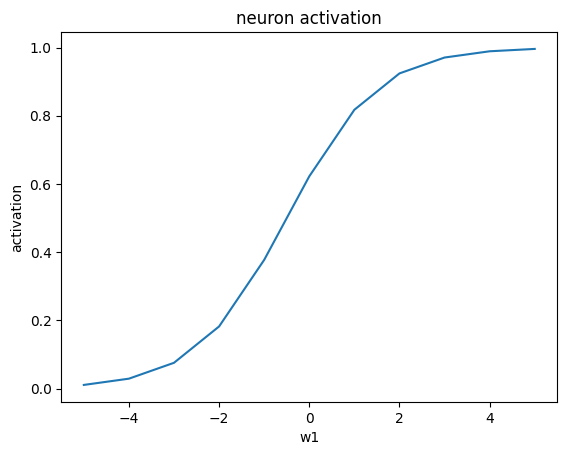

In [10]:
# TODO: Visualise l'effet des poids sur la sortie d'un neurone
#
# 1. Fixe x = [1.0, 0.5] et b = 0
# 2. Fais varier w₁ de -5 à 5 (garde w₂ = 1.0)
# 3. Pour chaque valeur de w₁, calcule la sortie du neurone
# 4. Trace la courbe : w₁ en abscisse, sortie du neurone en ordonnée
#
# Que constates-tu ? Comment le poids w₁ influence-t-il la sortie ?

# YOUR CODE HERE

x = np.array(object=[1.0, 0.5])
b = 0

r = []
ws = []
for i in range(-5, 5 +1):
    w = np.array(object=[i, 1.0])
    _, a = neuron(x, w, b)
    r.append(a)
    ws.append(i)

plt.plot(ws, r)
plt.xlabel("w1")
plt.ylabel("activation")
plt.title("neuron activation")


---
## Module 2 — Fonctions d'Activation et leurs Dérivées

**Objectif** : Implémenter les fonctions d'activation ET leurs dérivées.  
Les dérivées sont indispensables pour la backpropagation (Module 5).

### Les 3 fonctions essentielles

#### 1. Sigmoid
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
- Sortie entre 0 et 1 → interprétable comme une probabilité
- Problème : **vanishing gradient** — la dérivée tend vers 0 pour les valeurs extrêmes
- Dérivée : $\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$

#### 2. ReLU (Rectified Linear Unit)
$$\text{ReLU}(z) = \max(0, z)$$
- Simple, rapide, efficace — la plus utilisée dans les couches cachées
- Dérivée : $\text{ReLU}'(z) = \begin{cases} 1 & \text{si } z > 0 \\ 0 & \text{si } z \leq 0 \end{cases}$

#### 3. Softmax
$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$
- Transforme un vecteur de scores en **probabilités** (somme = 1)
- Utilisée en **dernière couche** pour la classification multiclasse
- Sa dérivée est plus complexe — on la combinera avec la cross-entropy (Module 5)

### Pourquoi les dérivées comptent ?
L'entraînement d'un réseau = trouver les poids qui **minimisent la loss**.  
Pour minimiser, on calcule le **gradient** (= direction de la pente) et on descend.  
Le gradient nécessite la dérivée de chaque opération, y compris les activations.

In [6]:
# TODO: Implémente la fonction sigmoid ET sa dérivée
#
# sigmoid(z)    : formule donnée ci-dessus
# sigmoid_deriv(z) : utilise la propriété σ'(z) = σ(z) * (1 - σ(z))
#
# Attention aux overflow : pour z très négatif, exp(-z) explose.
# Hint: np.clip(z, -500, 500) avant le calcul pour éviter les erreurs numériques

def sigmoid(z):
    # YOUR CODE HERE
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
    # YOUR CODE HERE
    return sigmoid(z) * (1 - sigmoid(z))

# Test
z_vals = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
print('z       :', z_vals)
print('σ(z)    :', np.round(sigmoid(z_vals), 4))        # attendu: [0.1192, 0.2689, 0.5, 0.7311, 0.8808]
print("σ'(z)   :", np.round(sigmoid_deriv(z_vals), 4))  # attendu: [0.1050, 0.1966, 0.25, 0.1966, 0.1050]

z       : [-2. -1.  0.  1.  2.]
σ(z)    : [0.1192 0.2689 0.5    0.7311 0.8808]
σ'(z)   : [0.105  0.1966 0.25   0.1966 0.105 ]


In [7]:
# TODO: Implémente la fonction ReLU ET sa dérivée
#
# relu(z)       : retourne z si z > 0, sinon 0
# relu_deriv(z) : retourne 1 si z > 0, sinon 0
#
# Hint: pense à np.maximum() ou np.where()

def relu(z):
    # YOUR CODE HERE
    return np.maximum(z, 0)

def relu_deriv(z):
    # YOUR CODE HERE
    return np.where(z > 0, 1, 0)

# Test
z_vals = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
print('z          :', z_vals)
print('ReLU(z)    :', relu(z_vals))        # attendu: [0, 0, 0, 1, 2]
print("ReLU'(z)   :", relu_deriv(z_vals))  # attendu: [0, 0, 0, 1, 1]

z          : [-2. -1.  0.  1.  2.]
ReLU(z)    : [0. 0. 0. 1. 2.]
ReLU'(z)   : [0 0 0 1 1]


In [8]:
# TODO: Implémente la fonction Softmax
#
# softmax(z) : transforme un vecteur de scores en probabilités
#
# PIÈGE CLASSIQUE : si z contient des grandes valeurs, exp(z) explose (overflow).
# Astuce de stabilité numérique : soustraire max(z) avant de calculer les exponentielles.
# Mathématiquement, softmax(z) = softmax(z - max(z))  (le résultat est identique)
#
# Hint: la fonction doit marcher pour :
#   - un vecteur 1D (un seul exemple)
#   - une matrice 2D (batch d'exemples, softmax sur chaque ligne)
#   Pour le cas 2D, pense à keepdims=True dans max() et sum()

def softmax(z):
    # YOUR CODE HERE
    z = z - np.max(z, keepdims=True, axis=-1)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, keepdims=True, axis=-1)

# Test 1D
z_test = np.array([2.0, 1.0, 0.1])
probs = softmax(z_test)
print(f'Scores  : {z_test}')
print(f'Softmax : {np.round(probs, 4)}')     # attendu: [0.6590, 0.2424, 0.0986]
print(f'Somme   : {probs.sum():.6f}')         # attendu: 1.000000

# Test 2D (batch)
z_batch = np.array([[2.0, 1.0, 0.1], [1.0, 3.0, 0.2]])
probs_batch = softmax(z_batch)
print(f'\nBatch softmax :\n{np.round(probs_batch, 4)}')
print(f'Somme par ligne : {probs_batch.sum(axis=1)}')  # attendu: [1.0, 1.0]

Scores  : [2.  1.  0.1]
Softmax : [0.659  0.2424 0.0986]
Somme   : 1.000000

Batch softmax :
[[0.659  0.2424 0.0986]
 [0.1131 0.836  0.0508]]
Somme par ligne : [1. 1.]


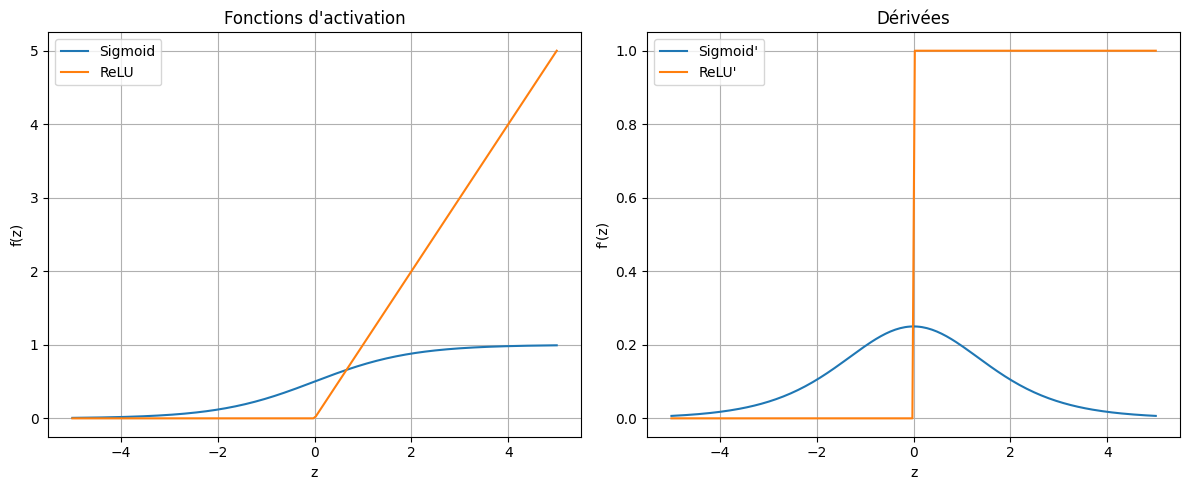

In [9]:
# TODO: Visualise les 3 fonctions d'activation et leurs dérivées
#
# Sur 2 sous-graphes (1 ligne, 2 colonnes) :
#   - Gauche : les fonctions sigmoid, relu sur z ∈ [-5, 5]
#   - Droite : leurs dérivées
#
# Hint: np.linspace(-5, 5, 200) pour générer les points
#       plt.subplot(1, 2, 1) et plt.subplot(1, 2, 2)

# YOUR CODE HERE

z = np.linspace(-5, 5, 200)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(z, sigmoid(z), label='Sigmoid')
plt.plot(z, relu(z), label='ReLU')
plt.title('Fonctions d\'activation')
plt.xlabel('z')
plt.ylabel('f(z)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(z, sigmoid_deriv(z), label="Sigmoid'")
plt.plot(z, relu_deriv(z), label="ReLU'")
plt.title('Dérivées')
plt.xlabel('z')
plt.ylabel("f'(z)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---
## Module 3 — Forward Propagation : De l'Entrée à la Sortie

**Objectif** : Comprendre et coder la propagation avant à travers un réseau multicouche.

### Qu'est-ce que le forward pass ?

C'est le calcul qui part des **entrées** (pixels de l'image) et traverse chaque couche
pour produire une **sortie** (probabilités pour chaque classe).

### D'un neurone à une couche

Une couche de `m` neurones, chacun recevant `n` entrées :
- Poids : matrice `W` de shape `(n, m)` — chaque colonne = les poids d'un neurone
- Biais : vecteur `b` de shape `(m,)` — un biais par neurone
- Pour un batch de `k` exemples, `X` est de shape `(k, n)`

```
Z = X @ W + b      # shape: (k, m)  — pré-activation
A = f(Z)            # shape: (k, m)  — post-activation
```

### Réseau complet : enchaîner les couches

Pour un réseau `784 → 128 → 64 → 10` :

```
Couche 1 : Z₁ = X    @ W₁ + b₁    →  A₁ = relu(Z₁)
Couche 2 : Z₂ = A₁   @ W₂ + b₂    →  A₂ = relu(Z₂)
Couche 3 : Z₃ = A₂   @ W₃ + b₃    →  A₃ = softmax(Z₃)   ← sortie finale
```

La sortie d'une couche devient l'entrée de la suivante. C'est tout.

### Initialisation des poids

**CRUCIAL** : si tous les poids sont à 0, tous les neurones apprennent la même chose.
On initialise les poids **aléatoirement**, avec de petites valeurs.

Méthode de base : `W = np.random.randn(n_in, n_out) * 0.01`  
Les biais sont initialisés à 0 : `b = np.zeros(n_out)`

In [11]:
# TODO: Initialise les poids et biais pour un réseau 784 → 128 → 64 → 10
#
# Crée un dictionnaire `params` contenant :
#   params['W1'] : shape (784, 128)
#   params['b1'] : shape (128,)
#   params['W2'] : shape (128, 64)
#   params['b2'] : shape (64,)
#   params['W3'] : shape (64, 10)
#   params['b3'] : shape (10,)
#
# Hint: les poids W multipliés par 0.01, les biais à 0
#       Attention aux dimensions : W de shape (entrées, sorties)

def init_params(layer_sizes):
    """
    Initialise les poids et biais pour un réseau avec les tailles de couches données.
    layer_sizes : liste, ex: [784, 128, 64, 10]
    Retourne : dict avec W1, b1, W2, b2, ...
    """
    # YOUR CODE HERE
    return {
        'W1': np.random.randn(layer_sizes[0], layer_sizes[1]),
        'b1': np.zeros(layer_sizes[1]),
        'W2': np.random.randn(layer_sizes[1], layer_sizes[2]),
        'b2': np.zeros(layer_sizes[2]),
        'W3': np.random.randn(layer_sizes[2], layer_sizes[3]),
        'b3': np.zeros(layer_sizes[3]),
    }

# Test
params = init_params([784, 128, 64, 10])
for key in sorted(params.keys()):
    print(f'{key} : shape {params[key].shape}')

# Vérifie que les poids sont petits et les biais à 0
print(f"\nW1 — mean: {params['W1'].mean():.6f}, std: {params['W1'].std():.4f}")
print(f"b1 — mean: {params['b1'].mean():.6f}")

W1 : shape (784, 128)
W2 : shape (128, 64)
W3 : shape (64, 10)
b1 : shape (128,)
b2 : shape (64,)
b3 : shape (10,)

W1 — mean: 0.000949, std: 1.0009
b1 — mean: 0.000000


In [19]:
# TODO: Implémente le forward pass complet
#
# Écris une fonction forward(X, params) qui :
#   1. Calcule Z1 = X @ W1 + b1,    A1 = relu(Z1)
#   2. Calcule Z2 = A1 @ W2 + b2,   A2 = relu(Z2)
#   3. Calcule Z3 = A2 @ W3 + b3,   A3 = softmax(Z3)
#   4. Retourne A3 (prédictions) ET un dictionnaire `cache` contenant
#      toutes les valeurs intermédiaires (Z1, A1, Z2, A2, Z3, A3)
#
# POURQUOI le cache ?
# → La backpropagation (Module 5) a besoin de TOUTES les valeurs
#   intermédiaires pour calculer les gradients. On les stocke maintenant.
#
# Hint: le cache doit contenir au minimum Z1, A1, Z2, A2, Z3, A3
#       Pense aussi à stocker X (entrée du réseau).

def forward(X, params):
    """
    Forward pass à travers le réseau.
    X      : shape (batch_size, 784)
    params : dict avec W1, b1, W2, b2, W3, b3
    Retourne : (A3, cache)
    """
    cache = dict()
    cache['X'] = X
    cache['Z1'] = cache['X'] @ params['W1'] + params['b1']
    cache['A1'] = relu(cache['Z1'])
    cache['Z2'] = cache['A1'] @ params['W2'] + params['b2']
    cache['A2'] = relu(cache['Z2'])
    cache['Z3'] = cache['A2'] @ params['W3'] + params['b3']
    cache['A3'] = softmax(cache['Z3'])
    return cache['A3'], cache


# Test avec des données aléatoires (5 exemples, 784 features)
X_fake = np.random.randn(5, 784)
predictions, cache = forward(X_fake, params)

print(f'Shape des prédictions : {predictions.shape}')   # attendu: (5, 10)
print(f'Somme des probas (ligne 0) : {predictions[0].sum():.6f}')  # attendu: ~1.0
print(f'Prédiction exemple 0 : {predictions[0].round(4)}')
print(f'\nClés du cache : {list(cache.keys())}')

Shape des prédictions : (5, 10)
Somme des probas (ligne 0) : 1.000000
Prédiction exemple 0 : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

Clés du cache : ['X', 'Z1', 'A1', 'Z2', 'A2', 'Z3', 'A3']


Avant normalisation : min=0, max=255
Après normalisation : min=0.00, max=1.00
X_train_flat shape : (60000, 784)
X_test_flat shape  : (10000, 784)


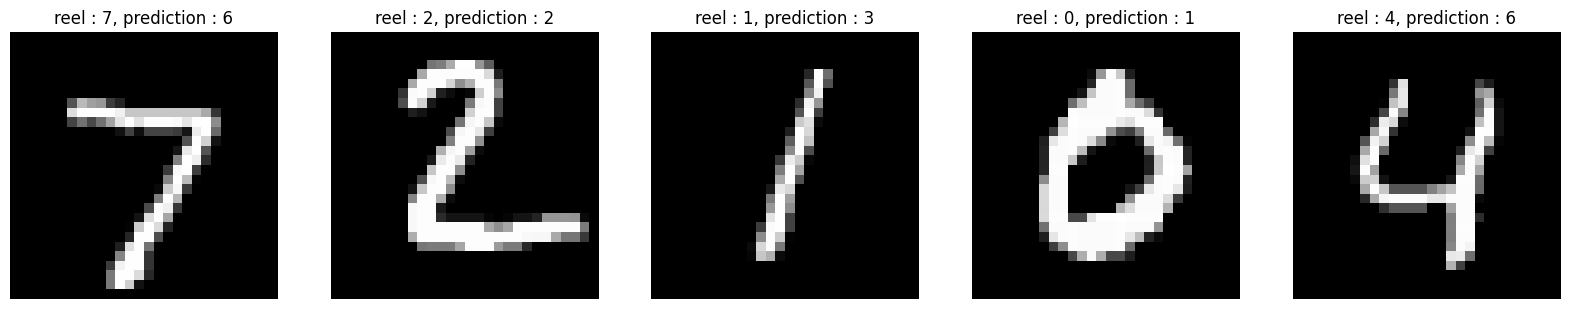

In [37]:
# TODO: Teste le forward pass sur de vraies données MNIST
#
# 1. Charge MNIST avec keras.datasets.mnist.load_data()
# 2. Normalise les pixels (/ 255.0)
# 3. Flatten les images en vecteurs de 784
# 4. Passe les 5 premières images dans le forward pass
# 5. Affiche les prédictions — sont-elles cohérentes ?
#    (Non ! Les poids sont aléatoires, le réseau n'a pas encore appris)

import tensorflow as tf  # uniquement pour charger les données !

# YOUR CODE HERE — chargement et preprocessing

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

print(f'Avant normalisation : min={X_train.min()}, max={X_train.max()}')
print(f'Après normalisation : min={X_train_norm.min():.2f}, max={X_train_norm.max():.2f}')

X_train_flat = X_train_norm.reshape(len(X_train_norm), 784)
X_test_flat = X_test_norm.reshape(len(X_test_norm), 784)

print(f'X_train_flat shape : {X_train_flat.shape}')
print(f'X_test_flat shape  : {X_test_flat.shape}') 

# YOUR CODE HERE — forward pass sur les 5 premières images

predictions, cache = forward(X_test_flat[:5], params)

# Affiche les images et les "prédictions" du réseau non entraîné
# (pour voir que sans entraînement, le réseau donne n'importe quoi)

plt.figure(figsize=(20, 5))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'reel : {y_test[i]}, prediction : {int(np.argmax(predictions[i]))}')
    plt.axis('off')


---
## Module 4 — Loss Functions : Mesurer l'Erreur

**Objectif** : Implémenter les fonctions qui mesurent **à quel point le réseau se trompe**.

### Pourquoi une loss function ?
Le réseau produit des prédictions. La loss mesure l'écart entre la prédiction et la réalité.
L'objectif de l'entraînement = **minimiser cette loss**.

### Cross-Entropy Loss (pour la classification)

Pour un exemple avec le vrai label `y` (one-hot) et les probabilités prédites `ŷ` :

$$L = -\sum_{i=0}^{9} y_i \cdot \log(\hat{y}_i)$$

En pratique, comme `y` est one-hot (un seul 1, le reste à 0) :
$$L = -\log(\hat{y}_{\text{classe correcte}})$$

**Intuition** :
- Si le réseau est sûr de la bonne classe ($\hat{y} \approx 1$) → $-\log(1) \approx 0$ → loss faible ✓
- Si le réseau se trompe ($\hat{y} \approx 0$) → $-\log(0) → +\infty$ → loss énorme ✗

### Pour un batch de `m` exemples
$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \sum_{j=0}^{9} y_{ij} \cdot \log(\hat{y}_{ij})$$

C'est la moyenne de la loss sur tout le batch.

In [43]:
# TODO: Implémente la Cross-Entropy Loss
#
# cross_entropy_loss(y_true, y_pred) :
#   y_true : labels one-hot, shape (m, 10)
#   y_pred : probabilités prédites (sortie softmax), shape (m, 10)
#   Retourne : scalaire (loss moyenne sur le batch)
#
# PIÈGE : log(0) = -inf → ajoute un epsilon (ex: 1e-15) aux prédictions
# Hint: np.clip() pour borner y_pred entre epsilon et 1-epsilon
#       np.log() pour le logarithme
#       np.mean() pour la moyenne sur le batch

def cross_entropy_loss(y_true, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return np.mean(np.sum(-y_true * np.log(y_pred), axis=1))

# Test
# Cas 1 : prédiction parfaite
y_true = np.array([[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]])  # classe 2
y_pred_good = np.array([[0.01, 0.01, 0.95, 0.01, 0.005, 0.005, 0.005, 0.003, 0.002, 0.0]])
print(f'Loss (bonne prédiction) : {cross_entropy_loss(y_true, y_pred_good):.4f}')  # attendu: ~0.05

# Cas 2 : prédiction catastrophique
y_pred_bad = np.array([[0.95, 0.01, 0.01, 0.01, 0.005, 0.005, 0.005, 0.003, 0.002, 0.0]])
print(f'Loss (mauvaise prédiction) : {cross_entropy_loss(y_true, y_pred_bad):.4f}')  # attendu: ~4.6


Loss (bonne prédiction) : 0.0513
Loss (mauvaise prédiction) : 4.6052


In [48]:
# TODO: Convertis les labels MNIST en one-hot encoding (à la main, sans keras !)
#
# Écris one_hot_encode(y, num_classes=10)
#   y : vecteur d'entiers, shape (m,)
#   Retourne : matrice one-hot, shape (m, num_classes)
#
# Exemple : y = [3, 1] → [[0,0,0,1,0,0,0,0,0,0],
#                           [0,1,0,0,0,0,0,0,0,0]]
#
# Hint: crée une matrice de zéros, puis place des 1 aux bons indices.
#       Pense à l'indexation avancée de NumPy : matrix[range(m), y] = 1

def one_hot_encode(y, num_classes=10):
    ohe = np.array(np.zeros((len(y), num_classes)))
    ohe[range(len(y)), y] = 1
    return ohe

# Test
y_sample = np.array([0, 3, 7, 9])
ohe = one_hot_encode(y_sample)
print(f'Labels : {y_sample}')
print(f'One-hot :\n{ohe}')
print(f'Shape : {ohe.shape}')  # attendu: (4, 10)

Labels : [0 3 7 9]
One-hot :
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Shape : (4, 10)


/tmp/ipykernel_41902/2019050791.py:11: RuntimeWarning: divide by zero encountered in log
  y = -np.log(np.array(x))


Text(0, 0.5, 'loss')

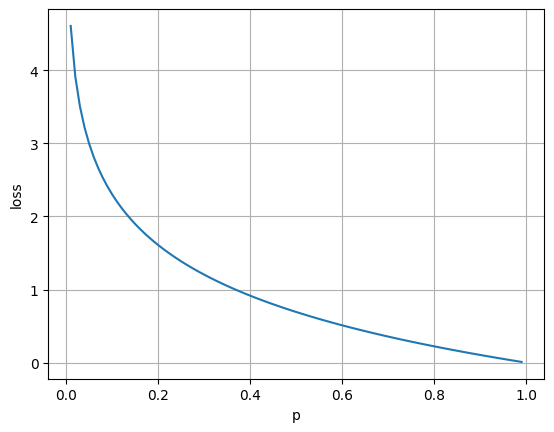

In [52]:
# TODO: Visualise la cross-entropy loss
#
# Trace la courbe L = -log(p) pour p allant de 0.01 à 1.0
# Que constates-tu ?
# → Quand p (la probabilité de la bonne classe) est proche de 1, la loss est faible
# → Quand p est proche de 0, la loss explose
#
# C'est pour ça que le réseau est "puni sévèrement" quand il est confiant ET faux.

x = [float(p) / 100.0 for p in range(100)]
y = -np.log(np.array(x))

plt.plot(x, y)
plt.grid()
plt.xlabel("p")
plt.ylabel("loss")


---
## Module 5 — Backpropagation : Le Cœur de l'Apprentissage

**Objectif** : Comprendre et implémenter l'algorithme qui calcule comment chaque poids
doit être modifié pour réduire la loss.

### Le principe : la Chain Rule (règle de la chaîne)

On veut calculer $\frac{\partial L}{\partial W}$ — de combien la loss change si on modifie un poids.

Le réseau est une composition de fonctions :
$$L = \text{loss}(\text{softmax}(A_2 \cdot W_3 + b_3), y)$$

La chain rule dit :
$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial A_3} \cdot \frac{\partial A_3}{\partial Z_3} \cdot \frac{\partial Z_3}{\partial A_2} \cdot \frac{\partial A_2}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial A_1} \cdot \frac{\partial A_1}{\partial Z_1} \cdot \frac{\partial Z_1}{\partial W_1}$$

On calcule ces dérivées **de la sortie vers l'entrée** — c'est pour ça que ça s'appelle **back**propagation.

### Les formules clés

**Propriété magique** : pour softmax + cross-entropy combinés :
$$\frac{\partial L}{\partial Z_3} = A_3 - Y$$
C'est la différence entre ce que le réseau prédit et la réalité. Élégant !

**Pour chaque couche `l`**, en notant $\delta_l = \frac{\partial L}{\partial Z_l}$ :

$$\frac{\partial L}{\partial W_l} = A_{l-1}^T \cdot \delta_l \quad / \quad m$$

$$\frac{\partial L}{\partial b_l} = \text{mean}(\delta_l, \text{axis}=0)$$

$$\delta_{l-1} = \delta_l \cdot W_l^T \odot f'(Z_{l-1})$$

Où :
- $A_{l-1}$ est l'activation de la couche précédente (stockée dans le cache !)
- $m$ est la taille du batch
- $\odot$ est la multiplication élément par élément
- $f'$ est la dérivée de la fonction d'activation

### En résumé, pour notre réseau 3 couches :

```
δ₃ = A₃ - Y                           (gradient de la sortie)
dW₃ = A₂ᵀ · δ₃ / m                    (gradient des poids couche 3)
db₃ = mean(δ₃, axis=0)                 (gradient des biais couche 3)

δ₂ = δ₃ · W₃ᵀ ⊙ relu'(Z₂)            (propage vers couche 2)
dW₂ = A₁ᵀ · δ₂ / m
db₂ = mean(δ₂, axis=0)

δ₁ = δ₂ · W₂ᵀ ⊙ relu'(Z₁)            (propage vers couche 1)
dW₁ = Xᵀ · δ₁ / m
db₁ = mean(δ₁, axis=0)
```

In [ ]:
# TODO: Implémente la backpropagation
#
# Écris backward(y_true, params, cache) qui :
#   1. Récupère les valeurs du cache (Z1, A1, Z2, A2, Z3, A3, X)
#   2. Calcule δ₃ = A₃ - Y  (gradient softmax + cross-entropy)
#   3. Calcule dW₃ et db₃
#   4. Propage δ₂ = δ₃ @ W₃.T * relu_deriv(Z₂)
#   5. Calcule dW₂ et db₂
#   6. Propage δ₁ = δ₂ @ W₂.T * relu_deriv(Z₁)
#   7. Calcule dW₁ et db₁
#   8. Retourne un dict `grads` avec dW1, db1, dW2, db2, dW3, db3
#
# IMPORTANT :
#   - m = nombre d'exemples dans le batch (y_true.shape[0])
#   - Division par m pour avoir la MOYENNE des gradients sur le batch
#   - Chaque dW doit avoir la même shape que le W correspondant
#   - Chaque db doit avoir la même shape que le b correspondant
#
# Hint: A₂ᵀ · δ₃ s'écrit cache['A2'].T @ delta3
#       N'oublie pas de diviser par m !

def backward(y_true, params, cache):
    """
    Backpropagation.
    y_true : one-hot labels, shape (m, 10)
    params : dict des poids
    cache  : dict des valeurs intermédiaires du forward pass
    Retourne : dict des gradients (dW1, db1, dW2, db2, dW3, db3)
    """
    # YOUR CODE HERE
    pass

# Test — vérifie les shapes des gradients
X_fake = np.random.randn(5, 784)
y_fake = one_hot_encode(np.array([0, 3, 5, 7, 2]))

predictions, cache = forward(X_fake, params)
grads = backward(y_fake, params, cache)

print('Shapes des gradients :')
for key in sorted(grads.keys()):
    param_key = key.replace('d', '', 1)   # dW1 → W1
    print(f'  {key} : {grads[key].shape}  (doit être = {params[param_key].shape})')
    assert grads[key].shape == params[param_key].shape, f'Shape mismatch pour {key} !'

In [ ]:
# TODO: Vérifie tes gradients par différences finies (gradient checking)
#
# Le gradient checking permet de vérifier que ta backprop est correcte
# en comparant le gradient analytique avec une approximation numérique :
#
#   dL/dw ≈ (L(w + ε) - L(w - ε)) / (2ε)    avec ε très petit (ex: 1e-5)
#
# Pour CHAQUE poids w dans un petit sous-ensemble :
#   1. Calcule la loss avec w + ε  →  loss_plus
#   2. Calcule la loss avec w - ε  →  loss_minus
#   3. grad_numerique = (loss_plus - loss_minus) / (2 * epsilon)
#   4. Compare avec le gradient de la backprop
#
# Hint: teste sur un petit réseau (ex: [4, 3, 2]) pour que ce soit rapide
#       Ne teste que quelques poids, pas tous !
#       La différence relative devrait être < 1e-5

def gradient_check(X, y, params, epsilon=1e-5, n_checks=5):
    """Vérifie les gradients par différences finies."""
    predictions, cache = forward(X, params)
    grads = backward(y, params, cache)

    print('Gradient Checking:')
    for key in ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']:
        param = params[key]
        grad = grads['d' + key]

        # Vérifie n_checks éléments aléatoires
        indices = [tuple(np.random.randint(0, s) for s in param.shape) for _ in range(n_checks)]

        for idx in indices:
            # YOUR CODE HERE
            # 1. Sauvegarde la valeur originale
            # 2. Calcule loss_plus (param[idx] + epsilon)
            # 3. Calcule loss_minus (param[idx] - epsilon)
            # 4. Restaure la valeur originale
            # 5. Calcule le gradient numérique
            # 6. Compare avec grad[idx]
            pass

# Test sur un petit réseau
small_params = init_params([4, 3, 2])
X_small = np.random.randn(3, 4)
y_small = one_hot_encode(np.array([0, 1, 0]), num_classes=2)
gradient_check(X_small, y_small, small_params)

---
## Module 6 — Gradient Descent : Mise à Jour des Poids

**Objectif** : Utiliser les gradients pour améliorer le réseau à chaque itération.

### Le principe

Le gradient indique la **direction de la montée** la plus raide de la loss.  
On veut **descendre**, donc on va dans la direction **opposée** :

$$W_{\text{new}} = W_{\text{old}} - \alpha \cdot \frac{\partial L}{\partial W}$$

Où $\alpha$ est le **learning rate** — le pas de descente.

### Learning rate
- **Trop grand** : le réseau "saute" par-dessus le minimum → instabilité, loss qui explose
- **Trop petit** : convergence très lente, peut rester coincé dans un minimum local
- **Valeur typique** : entre 0.001 et 0.1

### Types de gradient descent

| Type | Batch size | Avantage | Inconvénient |
|------|-----------|----------|--------------|
| **Batch GD** | Tout le dataset | Stable, converge bien | Lent, beaucoup de mémoire |
| **Stochastic GD** | 1 exemple | Rapide, peut s'échapper des minima locaux | Très bruité |
| **Mini-batch GD** | 32-256 exemples | Bon compromis | Le plus utilisé en pratique |

### L'algorithme complet

```
Pour chaque epoch :
    Mélanger les données
    Pour chaque mini-batch :
        1. Forward pass → prédictions + cache
        2. Calcul de la loss
        3. Backward pass → gradients
        4. Update : W = W - lr * dW,  b = b - lr * db
```

In [ ]:
# TODO: Implémente la mise à jour des poids (SGD basique)
#
# update_params(params, grads, learning_rate) :
#   Pour chaque poids W et biais b :
#     W = W - learning_rate * dW
#     b = b - learning_rate * db
#   Retourne les params mis à jour
#
# Hint: boucle sur les indices (1, 2, 3) et utilise f-strings pour les clés

def update_params(params, grads, learning_rate):
    # YOUR CODE HERE
    pass

# Test rapide
print(f"W1 avant update — mean: {params['W1'].mean():.6f}")
params = update_params(params, grads, learning_rate=0.1)
print(f"W1 après update — mean: {params['W1'].mean():.6f}")
print('(les valeurs doivent être légèrement différentes)')

In [ ]:
# TODO: Implémente la boucle d'entraînement pour UN epoch
#
# train_one_epoch(X, y, params, learning_rate, batch_size) :
#   1. Mélange les données (même permutation pour X et y !)
#   2. Découpe en mini-batches de taille batch_size
#   3. Pour chaque mini-batch :
#      a. Forward pass
#      b. Calcul de la loss
#      c. Backward pass
#      d. Update des poids
#   4. Retourne la loss moyenne sur l'epoch
#
# Hint pour le mélange :
#   indices = np.random.permutation(len(X))
#   X_shuffled, y_shuffled = X[indices], y[indices]
#
# Hint pour les mini-batches :
#   for i in range(0, len(X), batch_size):
#       X_batch = X_shuffled[i:i+batch_size]

def train_one_epoch(X, y, params, learning_rate, batch_size):
    # YOUR CODE HERE
    pass

# Test
params = init_params([784, 128, 64, 10])
# On va utiliser les vraies données MNIST chargées plus haut
# (assure-toi que X_train_flat et y_train_ohe existent)
# loss = train_one_epoch(X_train_flat, y_train_ohe, params, learning_rate=0.1, batch_size=128)
# print(f'Loss après 1 epoch : {loss:.4f}')

In [ ]:
# TODO: Visualise l'effet du learning rate
#
# Entraîne 3 réseaux identiques pendant 10 epochs avec des learning rates différents :
#   - lr = 0.001 (trop petit ?)
#   - lr = 0.1   (juste bien ?)
#   - lr = 5.0   (trop grand ?)
#
# Trace les 3 courbes de loss sur un même graphe.
# Que constates-tu ? Quel learning rate donne les meilleurs résultats ?
#
# Hint: pour chaque lr, réinitialise les params avec init_params()
#       et entraîne 10 epochs en gardant la loss de chaque epoch

# YOUR CODE HERE

---
## Module 7 — Assemblage : La Classe NeuralNetwork

**Objectif** : Rassembler tout le code dans une classe propre et réutilisable.

### Architecture de la classe

```python
class NeuralNetwork:
    def __init__(self, layer_sizes):    # initialise le réseau
    def forward(self, X):              # forward pass
    def compute_loss(self, y_true, y_pred):  # cross-entropy
    def backward(self, y_true):        # backpropagation
    def update(self, learning_rate):   # gradient descent
    def train(self, X, y, ...):        # boucle d'entraînement complète
    def predict(self, X):              # inférence
    def evaluate(self, X, y):          # accuracy sur un dataset
```

Tu as déjà codé toutes les briques — il faut maintenant les assembler.

In [ ]:
# TODO: Crée la classe NeuralNetwork
#
# C'est le gros morceau — tu assembles tout ce que tu as codé.
# Chaque méthode correspond à une fonction que tu as déjà implémentée.
#
# __init__(self, layer_sizes) :
#   - Stocke layer_sizes
#   - Initialise self.params avec la fonction init_params
#   - Initialise self.cache = {}
#   - Initialise self.grads = {}
#
# forward(self, X) :
#   - Même logique que ta fonction forward() du Module 3
#   - Stocke le cache dans self.cache
#   - Doit fonctionner pour N'IMPORTE quel nombre de couches (pas juste 3)
#
# compute_loss(self, y_true, y_pred) :
#   - Cross-entropy du Module 4
#
# backward(self, y_true) :
#   - Backprop du Module 5
#   - Stocke les gradients dans self.grads
#   - Doit fonctionner pour N'IMPORTE quel nombre de couches
#
# update(self, learning_rate) :
#   - Met à jour self.params avec self.grads
#
# predict(self, X) :
#   - Forward pass + argmax → retourne les classes prédites
#
# evaluate(self, X, y) :
#   - Calcule l'accuracy (y sont des entiers, pas one-hot)
#
# train(self, X_train, y_train, epochs, batch_size, learning_rate, X_val, y_val) :
#   - Boucle d'entraînement complète
#   - Affiche loss et accuracy à chaque epoch
#   - Retourne un historique (losses, train_accs, val_accs)
#
# CHALLENGE : rends le réseau GÉNÉRIQUE — qu'il fonctionne avec
# n'importe quelle architecture [784, 256, 128, 64, 10] par exemple.
# Hint: boucle sur le nombre de couches au lieu de hardcoder W1, W2, W3

class NeuralNetwork:
    def __init__(self, layer_sizes):
        # YOUR CODE HERE
        pass

    def forward(self, X):
        # YOUR CODE HERE
        pass

    def compute_loss(self, y_true, y_pred):
        # YOUR CODE HERE
        pass

    def backward(self, y_true):
        # YOUR CODE HERE
        pass

    def update(self, learning_rate):
        # YOUR CODE HERE
        pass

    def predict(self, X):
        # YOUR CODE HERE
        pass

    def evaluate(self, X, y):
        # YOUR CODE HERE
        pass

    def train(self, X_train, y_train, epochs=20, batch_size=128,
              learning_rate=0.1, X_val=None, y_val=None):
        # YOUR CODE HERE
        pass

# Test d'instanciation
nn = NeuralNetwork([784, 128, 64, 10])
print(f'Réseau créé : {nn.layer_sizes}')
print(f'Nombre de couches de poids : {len(nn.layer_sizes) - 1}')
for key in sorted(nn.params.keys()):
    print(f'  {key} : {nn.params[key].shape}')

---
## Module 8 — Entraînement sur MNIST

**Objectif** : Entraîner ton réseau from scratch sur les vrais chiffres manuscrits.

### Ce que tu vas faire
1. Préparer les données (normalisation, flatten, one-hot)
2. Créer un réseau 784 → 128 → 64 → 10
3. L'entraîner pendant 20-30 epochs
4. Tracer les courbes de loss et accuracy
5. Évaluer sur le test set
6. Afficher la confusion matrix

### Résultat attendu
Avec un MLP basique from scratch, tu peux espérer **~97% d'accuracy** sur MNIST.  
C'est comparable au MLP Keras du cours précédent — mais cette fois tu comprends chaque ligne !

In [ ]:
# TODO: Prépare les données MNIST
#
# 1. Charge MNIST (si pas déjà fait)
# 2. Normalise (/ 255.0)
# 3. Flatten (reshape en vecteurs de 784)
# 4. One-hot encode les labels (avec TA fonction, pas keras)
# 5. Crée un set de validation (ex: les 10000 dernières images du train)
#
# Hint: X_val = X_train_flat[-10000:], X_train_final = X_train_flat[:-10000]

# YOUR CODE HERE

In [ ]:
# TODO: Crée et entraîne le réseau
#
# nn = NeuralNetwork([784, 128, 64, 10])
# history = nn.train(
#     X_train_final, y_train_ohe_final,
#     epochs=30,
#     batch_size=128,
#     learning_rate=0.1,
#     X_val=X_val, y_val=y_val_labels
# )

# YOUR CODE HERE

In [ ]:
# TODO: Trace les courbes d'entraînement
#
# 2 graphiques côte à côte :
#   - Gauche : Loss en fonction des epochs
#   - Droite : Accuracy (train + validation) en fonction des epochs
#
# Hint: utilise l'historique retourné par nn.train()

# YOUR CODE HERE

In [ ]:
# TODO: Évalue sur le test set
#
# 1. Calcule l'accuracy sur le test set
# 2. Affiche un classification report (avec sklearn si tu veux)
# 3. Affiche la confusion matrix
# 4. Compare avec tes résultats Keras du cours précédent

# YOUR CODE HERE

In [ ]:
# TODO: Affiche des exemples de prédictions
#
# 1. Prends 20 images aléatoires du test set
# 2. Prédit avec ton réseau from scratch
# 3. Affiche chaque image avec le vrai label et la prédiction
#    (vert = correct, rouge = erreur)
# 4. Affiche aussi les probabilités softmax pour les cas intéressants

# YOUR CODE HERE

In [ ]:
# TODO: Analyse les erreurs
#
# 1. Trouve tous les exemples mal classés
# 2. Affiche 25 erreurs
# 3. Pour chaque erreur, affiche la distribution softmax
#    → sur quoi le réseau hésite-t-il ?
# 4. Compare les erreurs avec celles du réseau Keras
#    → sont-elles les mêmes ?

# YOUR CODE HERE

---
## Module 9 — Améliorations & Réflexion

**Objectif** : Comprendre ce qui peut être amélioré et comment les frameworks font mieux.

### Améliorations possibles

#### 1. Initialisation de He
Au lieu de `W * 0.01`, utilise :
$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}}}}\right)$$
Cela adapte la variance des poids au nombre d'entrées → convergence plus rapide avec ReLU.

#### 2. Momentum
Au lieu de juste descendre le gradient, on accumule la "vitesse" :
$$v = \beta \cdot v + (1 - \beta) \cdot \nabla W$$
$$W = W - \alpha \cdot v$$
Ça lisse les oscillations et accélère la convergence. $\beta = 0.9$ est standard.

#### 3. Learning Rate Decay
Réduire le learning rate au fil de l'entraînement :
$$\alpha_t = \alpha_0 \cdot \frac{1}{1 + \text{decay} \cdot t}$$

#### 4. Régularisation L2 (Weight Decay)
Ajouter un terme de pénalité à la loss pour garder les poids petits :
$$L_{\text{total}} = L_{\text{cross-entropy}} + \frac{\lambda}{2m} \sum W^2$$

In [ ]:
# TODO: Implémente l'initialisation de He
#
# Modifie ta fonction init_params (ou crée init_params_he) pour que :
#   W = np.random.randn(n_in, n_out) * sqrt(2 / n_in)
#
# Entraîne un nouveau réseau avec cette initialisation.
# Compare la convergence avec l'initialisation * 0.01

# YOUR CODE HERE

In [ ]:
# TODO: Implémente le Momentum
#
# Modifie ta méthode update() pour supporter le momentum :
#   1. Crée un dictionnaire self.velocities (même shapes que params, initialisé à 0)
#   2. À chaque update :
#      v[key] = beta * v[key] + (1 - beta) * grads[key]
#      params[key] -= learning_rate * v[key]
#
# Entraîne et compare avec le SGD basique.

# YOUR CODE HERE

In [ ]:
# TODO: Expérimente avec différentes architectures
#
# Teste au moins 3 architectures différentes :
#   1. Réseau peu profond : [784, 64, 10]
#   2. Réseau standard   : [784, 128, 64, 10]
#   3. Réseau profond    : [784, 256, 128, 64, 32, 10]
#
# Pour chacun :
#   - Entraîne 20 epochs
#   - Note l'accuracy finale
#   - Trace les courbes
#
# Questions :
#   - Plus profond = toujours mieux ?
#   - Quel est le temps d'entraînement de chaque ?
#   - Observe le nombre de paramètres

# YOUR CODE HERE

In [ ]:
# TODO: Comparaison finale — Ton réseau vs Keras
#
# 1. Crée un MLP identique avec Keras (même architecture, même epochs)
# 2. Compare :
#    - Accuracy finale
#    - Temps d'entraînement
#    - Courbes de convergence
# 3. Pourquoi Keras fait-il (probablement) mieux ?
#    Hint: Adam optimizer, meilleure initialisation, calcul GPU,
#          optimisations numériques sous le capot

# YOUR CODE HERE

---
## Récapitulatif — Ce que tu as appris

| Concept | Tu l'as codé toi-même ? | Module |
|---------|------------------------|--------|
| Neurone artificiel (somme pondérée + biais) | ✅ | 1 |
| Fonctions d'activation (sigmoid, ReLU, softmax) | ✅ | 2 |
| Dérivées des fonctions d'activation | ✅ | 2 |
| Forward propagation couche par couche | ✅ | 3 |
| Initialisation des poids | ✅ | 3 |
| Cross-entropy loss | ✅ | 4 |
| One-hot encoding | ✅ | 4 |
| Backpropagation (chain rule, gradients) | ✅ | 5 |
| Gradient checking | ✅ | 5 |
| Gradient descent (SGD, mini-batch) | ✅ | 6 |
| Impact du learning rate | ✅ | 6 |
| Classe NeuralNetwork complète | ✅ | 7 |
| Entraînement et évaluation sur MNIST | ✅ | 8 |
| Initialisation de He, Momentum | ✅ | 9 |

---

### Ce que Keras/TensorFlow/PyTorch font en plus

Maintenant que tu comprends les fondations, voici ce que les frameworks ajoutent :

- **Optimiseurs avancés** : Adam, RMSProp, AdaGrad — combinaisons malines de momentum + learning rate adaptatif
- **Calcul GPU** : les multiplications matricielles sont massivement parallélisées sur GPU (CUDA)
- **Automatic Differentiation** : calcul automatique de TOUS les gradients — plus besoin de dériver à la main
- **Couches spécialisées** : Conv2D, LSTM, Attention, BatchNorm — des opérations optimisées
- **Régularisation** : Dropout, L1/L2, Early Stopping — intégrés et testés
- **Data pipelines** : chargement efficace des données, augmentation à la volée

**Mais tout repose sur les mêmes principes que tu viens de coder.**  
Forward → Loss → Backward → Update. C'est tout.

---

### Pour aller plus loin

1. **Ajoute des couches convolutives from scratch** : le même principe mais avec des filtres 2D
2. **Implémente Adam** : combine momentum + RMSProp (l'optimiseur le plus populaire)
3. **Implémente Dropout** : masque aléatoire pendant le training, pas pendant l'inférence
4. **Implémente BatchNorm** : normalise les activations à chaque couche
5. **Lis le papier original** de Rumelhart, Hinton & Williams (1986) sur la backpropagation

---

### Notes personnelles

*(Ce que tu as compris, les difficultés rencontrées, tes intuitions...)*

```
[Date] :
```